In [1]:
import psutil
import sys
# !{sys.executable} --version
# !{sys.executable} -m pip install shap --upgrade 
import joblib
import time
from shutil import copy
import numpy as np
import pandas as pd
#import tensorflow as tf
import os
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm
import pickle
import xgboost as xgb

from glob import glob
import psi4
from helper_CC_ML_spacial import *

import pyscf
import pyscf.cc
import pyscf.mcscf
import ffsim
import numpy as np
import matplotlib.pyplot as plt

from qiskit import QuantumCircuit, QuantumRegister
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit_ibm_runtime import SamplerV2 as Sampler

  Threads set to 12 by Python driver.


In [2]:
basis_sets = ['STO-3G','cc-pVDZ','aug-cc-pVDZ']

In [3]:
basis = basis_sets[2]
n = 100
model_name = f'optimised_{basis}_best_model_{n}.pkl'

In [4]:
model = joblib.load(os.path.join(os.path.expanduser('~'),'DDLUCJ', 'machine_learning', 'out', model_name))

/home/amousso3/miniconda3/envs/ddlucj-env/lib/python3.12/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator MinMaxScaler from version 1.5.2 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/amousso3/miniconda3/envs/ddlucj-env/lib/python3.12/pickle.py:1760: UserWarning: [22:48:37] WARNING: /workspace/src/collective/../data/../common/error_msg.h:82: If you are loading a serialized model (like pickle in Python, RDS in R) or
configuration generated by an older version of XGBoost, please export the model by calling
`Booster.save_model` from that version first, then load it back in current version. See:

    https://xgboost.readthedocs.io/en/stable/tutorials/saving_model.html

for more details about differences between saving model and serializing.

  setsta

# These are the machine learning features, these will be useful later

In [5]:
# properties=['Evir1', 'Hvir1', 'Jvir1', 'Kvir1', 'Evir2', 'Hvir2', 'Jvir2', 'Kvir2', 'Eocc1', 'Jocc1', 'Kocc1', 'Hocc1','Eocc2', 'Jocc2', 'Kocc2', 'Hocc2', 'Jia1', 'Jia2', 'Kia1', 'Kia2','diag', 'orbdiff', 'doublecheck', 't2start', 't2mag', 't2sign', 'Jia1mag', 'Jia2mag','Kia1mag', 'Kia2mag','t2']
properties=['Evir1', 'Hvir1', 'Jvir1', 'Kvir1', 'Evir2', 'Hvir2', 'Jvir2', 'Kvir2', 'Eocc1', 'Jocc1', 'Kocc1', 'Hocc1','Eocc2', 'Jocc2', 'Kocc2', 'Hocc2', 'Jia1', 'Jia2', 'Kia1', 'Kia2','diag', 'orbdiff', 'doublecheck', 't2start', 't2mag', 't2sign', 'Jia1mag', 'Jia2mag','Kia1mag', 'Kia2mag']

# Use the basis sets for both Psi4 and PySCF

# Load in the xyz coordinates of the system and then run Psi4 with the Psi4Numpy code we use for DDCC

In [6]:
with open(os.path.join(os.path.expanduser('~'),'DDLUCJ', 'machine_learning', 'out','train_names.txt'), "r") as f:
    lines = f.readlines()

ml_files = [element[:-1] for element in lines]

with open(os.path.join(os.path.expanduser('~'),'DDLUCJ', 'machine_learning', 'out','test_names.txt'), "r") as f:
    lines = f.readlines()

ml_files.extend([element[:-1] for element in lines])

In [7]:
molecule_types = ["ammonia", "methane", "ethylene", "ethane", "water", "formaldehyde", "methanol"]
home = os.path.expanduser("~")
data_dir = os.path.join(home, "DDLUCJ", "machine_learning", "data")
# pick one file per type not in ml_files
selected = []
for mol in molecule_types:
    for fname in os.listdir(data_dir):
        if fname.startswith(mol) and fname.endswith(".xyz") and fname not in ml_files:
            selected.append(fname)
            break  # stop after first match

mol_file = selected[4]

In [8]:
with open(os.path.join(os.path.expanduser('~'),'DDLUCJ', 'machine_learning', 'data', mol_file),'r') as f:
    text=f.read()

mol = psi4.geometry(text)
print(text)
psi4.core.clean()
psi4.core.be_quiet()

psi4.set_options({'basis': basis,
                  'scf_type':     'pk',
                  'reference':    'rohf',
                  'mp2_type':     'conv',
                  'e_convergence': 1e-8,
                  'd_convergence': 1e-8})

rhf_e, scf_wfn = psi4.energy('scf', return_wfn=True)
scf_e, scf_wfn = psi4.energy('scf', return_wfn=True)

A=HelperCCEnergy(mol, rhf_e, scf_wfn,freeze_core=False)


O 10 10 10 
H 10.5541 10.1925 10.7596 
H 10.5285 10.0337 9.20182 
units angstrom
symmetry c1

Computing RHF reference.


/home/amousso3/DDLUCJ/machine_learning/injection/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/home/amousso3/DDLUCJ/machine_learning/injection/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/home/amousso3/DDLUCJ/machine_learning/injection/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})



Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 41 basis functions.
(41, 41)
(41, 41)
Building initial guess...

..initialized CCSD in 0.530 seconds.



In [9]:
A.compute_energy()

CCSD Iteration   0: CCSD correlation = -0.221713291986673   dE =  2.21713E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.223682650187500   dE = -1.96936E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.228194087444688   dE = -4.51144E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.228610878286795   dE = -4.16791E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.229210915068445   dE = -6.00037E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.229248257850250   dE = -3.73428E-05   DIIS = 4
CCSD Iteration   6: CCSD correlation = -0.229249751412312   dE = -1.49356E-06   DIIS = 5
CCSD Iteration   7: CCSD correlation = -0.229250423465227   dE = -6.72053E-07   DIIS = 6
CCSD Iteration   8: CCSD correlation = -0.229250126329516   dE =  2.97136E-07   DIIS = 7
CCSD Iteration   9: CCSD correlation = -0.229250090452317   dE =  3.58772E-08   DIIS = 7
CCSD Iteration  10: CCSD correlation = -0.229250111143851   dE = -2.06915E-08   DIIS = 7
CCSD Iteration  11: CCSD c

np.float64(-0.22925008467872302)

In [10]:
top5 = ['doublecheck', 't2start', 't2mag', 'orbdiff', 'diag']

In [11]:
X= np.vstack([getattr(A,i).flatten() for i in top5]).T
y = model.predict(X)
# X=A.t2.flatten()

In [12]:
np.isclose(y.reshape(*A.t2.shape), A.t2, atol=1e-4)

array([[[[ True,  True,  True, ...,  True,  True,  True],
         [ True,  True,  True, ...,  True,  True,  True],
         [ True,  True,  True, ...,  True,  True,  True],
         ...,
         [ True,  True,  True, ...,  True,  True,  True],
         [ True,  True,  True, ...,  True,  True,  True],
         [ True,  True,  True, ...,  True,  True,  True]],

        [[ True,  True,  True, ...,  True,  True,  True],
         [ True,  True,  True, ...,  True,  True,  True],
         [ True,  True,  True, ...,  True,  True,  True],
         ...,
         [ True,  True,  True, ...,  True,  True,  True],
         [ True,  True,  True, ...,  True,  True,  True],
         [ True,  True,  True, ...,  True,  True,  True]],

        [[ True,  True,  True, ...,  True,  True,  True],
         [ True,  True,  True, ...,  True,  True,  True],
         [ True,  True,  True, ...,  True,  True,  True],
         ...,
         [ True,  True,  True, ...,  True,  True,  True],
         [ True,  True,  T

In [13]:
molecule = "H2O"

# Specify molecule properties
open_shell = False   
spin_sq = 0          # singlet

# Define active space
n_frozen = 0         # freeze N 1s core orbital
num_orbitals = 7     # total orbitals in active space 
n_electrons = 10     # all valence electrons

In [14]:
print(text)

O 10 10 10 
H 10.5541 10.1925 10.7596 
H 10.5285 10.0337 9.20182 
units angstrom
symmetry c1



In [15]:
lines = text.split('\n')

# Slice the list to exclude the last two lines
modified_lines = lines[:-3]

# Join the remaining lines back into a single string
text_cleaned = '\n'.join(modified_lines)
print(text_cleaned)

O 10 10 10 
H 10.5541 10.1925 10.7596 
H 10.5285 10.0337 9.20182 


In [16]:
from pyscf import gto, scf

mol_fcidump = gto.Mole()
# mol_fcidump.build()
# mol_fcidump.symmetry = False
mol_fcidump.build(
    atom=text_cleaned,
    basis=basis,
    symmetry='c1',
)
# mol_fcidump.symmetry = False
# scf = scf.RHF(mol_fcidump).from_fcidump(molecule + '_INTDUMP', molpro_orbsym=False).run()
scf = scf.RHF(mol_fcidump).run()
# scf.kernel()

num_elec_a = (n_electrons + mol_fcidump.spin) // 2
num_elec_b = (n_electrons - mol_fcidump.spin) // 2
print(f"CAS({num_elec_a+num_elec_b},{num_orbitals})\nalpha={num_elec_a}\nbeta={num_elec_b}")

cas = pyscf.mcscf.CASCI(scf, num_orbitals, (num_elec_a, num_elec_b),ncore=0)

# cas = pyscf.mcscf.CASCI(scf, num_orbitals, num_elec_a+num_elec_b)
active_space = list(range(cas.ncore,cas.ncore+cas.ncas))
print(active_space)

# print(num_orbitals, (num_elec_a, num_elec_b))
mo = cas.sort_mo(active_space, base=0)
hcore, nuclear_repulsion_energy = cas.get_h1cas(mo)
eri = pyscf.ao2mo.restore(1, cas.get_h2cas(mo), num_orbitals)

# Compute exact energy
exact_energy = cas.run().e_tot

converged SCF energy = -76.0409222170656
CAS(10,7)
alpha=5
beta=5
[0, 1, 2, 3, 4, 5, 6]
CASCI E = -76.0409824084290  E(CI) = -85.2095091366677  S^2 = 0.0000000


In [17]:
ncore = cas.ncore
ndocc = len(np.argwhere(scf.mo_occ[active_space] == 2))
nvirt = len(np.argwhere(scf.mo_occ[active_space] == 0))

# now build the slices
t1_slice = np.s_[ncore:ndocc, :nvirt]
t2_slice = np.s_[ncore:ndocc, ncore:ndocc, :nvirt, :nvirt]

# Give distinct names to the different t2 amplitudes to avoid mix ups

In [18]:
# Input 1: Exact (w/ MP2 guess)
# Grier : t1_exact = A.t1[cas.ncore:len(np.argwhere(scf.mo_occ[active_space]==2)),:len(np.argwhere(scf.mo_occ[active_space]==0))]
# Grier: t2_exact = A.t2[cas.ncore:len(np.argwhere(scf.mo_occ[active_space]==2)),cas.ncore:len(np.argwhere(scf.mo_occ[active_space]==2)),:len(np.argwhere(scf.mo_occ[active_space]==0)),:len(np.argwhere(scf.mo_occ[active_space]==0))]
t1_exact = A.t1[t1_slice]
t2_exact = A.t2[t2_slice]


# Input 2: Zeroes
t1_zeros = np.zeros_like(t1_exact)
t2_zeros = np.zeros_like(t2_exact)

# Input 3: random numbers
t2_rand = np.random.uniform(low=-100, high=100, size=t2_exact.shape)
t1_rand = np.random.uniform(low=-100, high=100, size=t1_exact.shape)

# Input 4: ML Predicted values (t1 as zeroes)
t2_predicted = y.reshape(*A.t2.shape)[t2_slice]

# Input 5: MP2 guess (t1 as zeroes)
t2_MP2 = A.t2start[t2_slice]

In [19]:
np.isclose(t2_predicted, t2_exact, atol=1e-2)

array([[[[ True,  True],
         [ True,  True]],

        [[ True,  True],
         [ True,  True]],

        [[ True,  True],
         [ True,  True]],

        [[ True,  True],
         [ True,  True]],

        [[ True,  True],
         [ True,  True]]],


       [[[ True,  True],
         [ True,  True]],

        [[ True,  True],
         [ True,  True]],

        [[ True,  True],
         [ True,  True]],

        [[ True,  True],
         [ True,  True]],

        [[ True,  True],
         [ True,  True]]],


       [[[ True,  True],
         [ True,  True]],

        [[ True,  True],
         [ True,  True]],

        [[ True,  True],
         [ True,  True]],

        [[ True,  True],
         [ True,  True]],

        [[ True,  True],
         [ True,  True]]],


       [[[ True,  True],
         [ True,  True]],

        [[ True,  True],
         [ True,  True]],

        [[ True,  True],
         [ True,  True]],

        [[ True,  True],
         [ True,  True]],

      

# The code below generates the quantum circuit, submits a job to a QC and processes the data afterwards

To benchmark the DDLUCJ, we have to benchmark it against the classic LUCJ, rLUCJ, zLUCJ, and MPLUCJ, so for each molecule, we must run 5 different circuits per basis set.

So for each molecule we run $5 \times 3 = 15$ circuits. The results for each job will have its own job id.

For 7 molecules, that will be 85 circuits, and afterwards for the larger organic molecules and acene chains, it could take an additional 10-40 circuits.

The number of orbitals cannot exceed 156.

In [20]:
n_reps = 1
alpha_alpha_indices = [(p, p + 1) for p in range(num_orbitals - 1)]
alpha_beta_indices = [(p, p) for p in range(0, num_orbitals, 4)]

ucj_op = ffsim.UCJOpSpinBalanced.from_t_amplitudes(
    t2=t2_MP2,
    t1=t1_zeros,
    n_reps=n_reps,
    interaction_pairs=(alpha_alpha_indices, alpha_beta_indices),
)

nelec = (num_elec_a, num_elec_b)

# create an empty quantum circuit
qubits = QuantumRegister(2 * num_orbitals, name="q")
circuit = QuantumCircuit(qubits)

# prepare Hartree-Fock state as the reference state and append it to the quantum circuit
circuit.append(ffsim.qiskit.PrepareHartreeFockJW(num_orbitals, nelec), qubits)
print(len(circuit.qubits))  # length must be 16
# apply the UCJ operator to the reference state
circuit.append(ffsim.qiskit.UCJOpSpinBalancedJW(ucj_op), qubits)
circuit.measure_all()

14


In [21]:
t1_rand

array([[-11.28015546,  10.824643  ],
       [ 37.15151916,   3.13988214],
       [  1.25459823, -26.16985468],
       [ -8.12569037, -22.05349519],
       [-16.84182056,  31.45833721]])

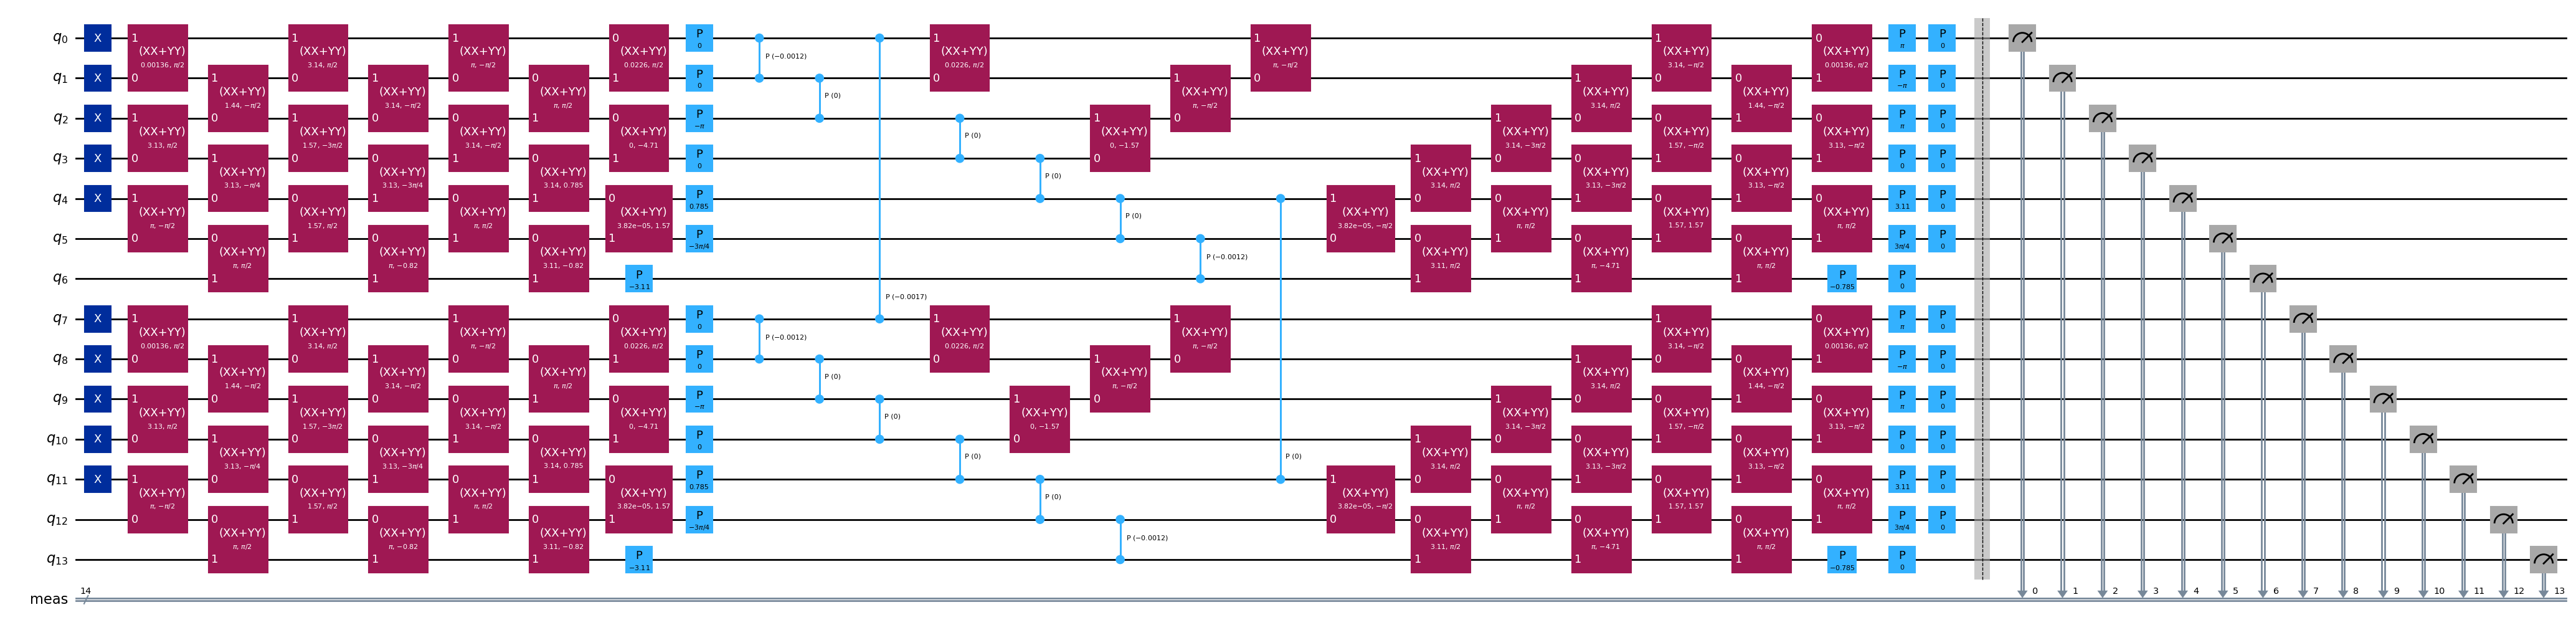

In [22]:
circuit.decompose(reps=2).draw('mpl',fold=-1)

In [23]:
fig = circuit.decompose(reps=2).draw('mpl', fold=-1)
# Save to file (PDF, PNG, SVG, etc.)
fig.savefig("decomposed_circuit.png", dpi=300, bbox_inches="tight")


In [24]:
instance = 'crn:v1:bluemix:public:quantum-computing:us-east:a/d2c50f33c43a44abb94280706332351d:887437c2-b2f6-4d10-9b6f-619ed19e7315::'

In [25]:
service = QiskitRuntimeService.save_account(
    token="VS8Yq_PWwvy_K6kN7RWnT1_yEZCmUnBrexv0UYwA_ygc", # IBM Cloud API key.
    # Your token is confidential. Do not share your token in public code.
    instance="crn:v1:bluemix:public:quantum-computing:us-east:a/d2c50f33c43a44abb94280706332351d:887437c2-b2f6-4d10-9b6f-619ed19e7315::", # Optionally specify the instance to use.
    # Additionally, instances of a certain plan type are excluded if the plan name is not specified.
    set_as_default=True, # Optionally set these as your default credentials.
    overwrite=True
  )

In [26]:
from qiskit_ibm_runtime.fake_provider import FakeSherbrooke

service = QiskitRuntimeService()

backend = service.backend("ibm_quebec")
# backend = FakeSherbrooke()

In [27]:
from typing import Sequence

import rustworkx
from qiskit.providers import BackendV2
from rustworkx import NoEdgeBetweenNodes, PyGraph

IBM_TWO_Q_GATES = {"cx", "ecr", "cz"}


def create_linear_chains(num_orbitals: int) -> PyGraph:
    """In zig-zag layout, there are two linear chains (with connecting qubits between
    the chains). This function creates those two linear chains: a rustworkx PyGraph
    with two disconnected linear chains. Each chain contains `num_orbitals` number
    of nodes, i.e., in the final graph there are `2 * num_orbitals` number of nodes.

    Args:
        num_orbitals (int): Number orbitals or nodes in each linear chain. They are
            also known as alpha-alpha interaction qubits.

    Returns:
        A rustworkx.PyGraph with two disconnected linear chains each with `num_orbitals`
            number of nodes.
    """
    G = rustworkx.PyGraph()

    for n in range(num_orbitals):
        G.add_node(n)

    for n in range(num_orbitals - 1):
        G.add_edge(n, n + 1, None)

    for n in range(num_orbitals, 2 * num_orbitals):
        G.add_node(n)

    for n in range(num_orbitals, 2 * num_orbitals - 1):
        G.add_edge(n, n + 1, None)

    return G


def create_lucj_zigzag_layout(
    num_orbitals: int, backend_coupling_graph: PyGraph
) -> tuple[PyGraph, int]:
    """This function creates the complete zigzag graph that 'can be mapped' to a IBM QPU with
    heavy-hex connectivity (the zigzag must be an isomorphic sub-graph to the QPU/backend
    coupling graph for it to be mapped).
    The zigzag pattern includes both linear chains (alpha-alpha interactions) and connecting
    qubits between the linear chains (alpha-beta interactions).

    Args:
        num_orbitals (int): Number of orbitals, i.e., number of nodes in each alpha-alpha linear chain.
        backend_coupling_graph (PyGraph): The coupling graph of the backend on which the LUCJ ansatz
            will be mapped and run. This function takes the coupling graph as a undirected
            `rustworkx.PyGraph` where there is only one 'undirected' edge between two nodes,
            i.e., qubits. Usually, the coupling graph of a IBM backend is directed (e.g., Eagle devices
            such as ibm_sherbrooke) or may have two edges between two nodes (e.g., Heron `ibm_torino`).
            A user needs to be make such graphs undirected and/or remove duplicate edges to make them
            compatible with this function.

    Returns:
        G_new (PyGraph): The graph with IBM backend compliant zigzag pattern.
        num_alpha_beta_qubits (int): Number of connecting qubits between the linear chains
            in the zigzag pattern. While we want as many connecting (alpha-beta) qubits between
            the linear (alpha-alpha) chains, we cannot accommodate all due to qubit and connectivity
            constraints of backends. This is the maximum number of connecting qubits the zigzag pattern
            can have while being backend compliant (i.e., isomorphic to backend coupling graph).
    """
    isomorphic = False
    G = create_linear_chains(num_orbitals=num_orbitals)

    num_iters = num_orbitals
    while not isomorphic:
        G_new = G.copy()
        num_alpha_beta_qubits = 0
        for n in range(num_iters):
            if n % 4 == 0:
                new_node = 2 * num_orbitals + num_alpha_beta_qubits
                G_new.add_node(new_node)
                G_new.add_edge(n, new_node, None)
                G_new.add_edge(new_node, n + num_orbitals, None)
                num_alpha_beta_qubits = num_alpha_beta_qubits + 1
        isomorphic = rustworkx.is_subgraph_isomorphic(
            backend_coupling_graph, G_new
        )
        num_iters -= 1

    return G_new, num_alpha_beta_qubits


def lightweight_layout_error_scoring(
    backend: BackendV2,
    virtual_edges: Sequence[Sequence[int]],
    physical_layouts: Sequence[int],
    two_q_gate_name: str,
) -> list[list[list[int], float]]:
    """Lightweight and heuristic function to score isomorphic layouts. There can be many zigzag patterns,
    each with different set of physical qubits, that can be mapped to a backend. Some of them may
    include less noise qubits and couplings than others. This function computes a simple error score
    for each such layout. It sums up 2Q gate error for all couplings in the zigzag pattern (layout) and
    measurement of errors of physical qubits in the layout to compute the error score.

    Note:
        This lightweight scoring can be refined using concepts such as mapomatic.

    Args:
        backend (BackendV2): A backend.
        virtual_edges (Sequence[Sequence[int]]): Edges in the device compliant zigzag pattern where
            nodes are numbered from 0 to (2 * num_orbitals + num_alpha_beta_qubits).
        physical_layouts (Sequence[int]): All physical layouts of the zigzag pattern that are isomorphic
            to each other and to the larger backend coupling map.
        two_q_gate_name (str): The name of the two-qubit gate of the backend. The name is used for fetching
            two-qubit gate error from backend properties.

    Returns:
        scores (list): A list of lists where each sublist contains two items. First item is the layout, and
            second item is a float representing error score of the layout. The layouts in the `scores` are
            sorted in the ascending order of error score.
    """
    props = backend.properties()
    scores = []
    for layout in physical_layouts:
        total_2q_error = 0
        for edge in virtual_edges:
            physical_edge = (layout[edge[0]], layout[edge[1]])
            try:
                ge = props.gate_error(two_q_gate_name, physical_edge)
            except Exception:
                ge = props.gate_error(two_q_gate_name, physical_edge[::-1])
            total_2q_error += ge
        total_measurement_error = 0
        for qubit in layout:
            meas_error = props.readout_error(qubit)
            total_measurement_error += meas_error
        scores.append([layout, total_2q_error + total_measurement_error])

    return sorted(scores, key=lambda x: x[1])


def _make_backend_cmap_pygraph(backend: BackendV2) -> PyGraph:
    graph = backend.coupling_map.graph
    if not graph.is_symmetric():
        graph.make_symmetric()
    backend_coupling_graph = graph.to_undirected()

    edge_list = backend_coupling_graph.edge_list()
    removed_edge = []
    for edge in edge_list:
        if set(edge) in removed_edge:
            continue
        try:
            backend_coupling_graph.remove_edge(edge[0], edge[1])
            removed_edge.append(set(edge))
        except NoEdgeBetweenNodes:
            pass

    return backend_coupling_graph


def get_zigzag_physical_layout(
    num_orbitals: int, backend: BackendV2, score_layouts: bool = True
) -> tuple[list[int], int]:
    """The main function that generates the zigzag pattern with physical qubits that can be used
    as an `intial_layout` in a preset passmanager/transpiler.

    Args:
        num_orbitals (int): Number of orbitals.
        backend (BackendV2): A backend.
        score_layouts (bool): Optional. If `True`, it uses the `lightweight_layout_error_scoring`
            function to score the isomorphic layouts and returns the layout with less erroneous qubits.
            If `False`, returns the first isomorphic subgraph.

    Returns:
        A tuple of device compliant layout (list[int]) with zigzag pattern and an int representing
            number of alpha-beta-interactions.
    """
    backend_coupling_graph = _make_backend_cmap_pygraph(backend=backend)

    G, num_alpha_beta_qubits = create_lucj_zigzag_layout(
        num_orbitals=num_orbitals,
        backend_coupling_graph=backend_coupling_graph,
    )

    isomorphic_mappings = rustworkx.vf2_mapping(
        backend_coupling_graph, G, subgraph=True
    )
    isomorphic_mappings = list(isomorphic_mappings)

    edges = list(G.edge_list())

    layouts = []
    for mapping in isomorphic_mappings:
        initial_layout = [None] * (2 * num_orbitals + num_alpha_beta_qubits)
        for key, value in mapping.items():
            initial_layout[value] = key
        layouts.append(initial_layout)

    two_q_gate_name = IBM_TWO_Q_GATES.intersection(
        backend.configuration().basis_gates
    ).pop()

    if score_layouts:
        scores = lightweight_layout_error_scoring(
            backend=backend,
            virtual_edges=edges,
            physical_layouts=layouts,
            two_q_gate_name=two_q_gate_name,
        )

        return scores[0][0][:-num_alpha_beta_qubits], num_alpha_beta_qubits

    return layouts[0][:-num_alpha_beta_qubits], num_alpha_beta_qubits

In [28]:
initial_layout, _ = get_zigzag_physical_layout(num_orbitals, backend=backend)

# When using zeroes to initialize, optimization lvl 3 removes phase gates with small angles, but it gets stuck for some reason
pass_manager = generate_preset_pass_manager(
    optimization_level=3, backend=backend, initial_layout=initial_layout
)

# without PRE_INIT passes
isa_circuit = pass_manager.run(circuit)
print(f"Gate counts (w/o pre-init passes): {isa_circuit.count_ops()}")

# with PRE_INIT passes
# We will use the circuit generated by this pass manager for hardware execution
pass_manager.pre_init = ffsim.qiskit.PRE_INIT
isa_circuit = pass_manager.run(circuit)
print(f"Gate counts (w/ pre-init passes): {isa_circuit.count_ops()}")

Gate counts (w/o pre-init passes): OrderedDict({'sx': 388, 'rz': 353, 'cz': 150, 'x': 33, 'measure': 14, 'barrier': 1})
Gate counts (w/ pre-init passes): OrderedDict({'sx': 315, 'rz': 285, 'cz': 130, 'x': 28, 'measure': 14, 'barrier': 1})


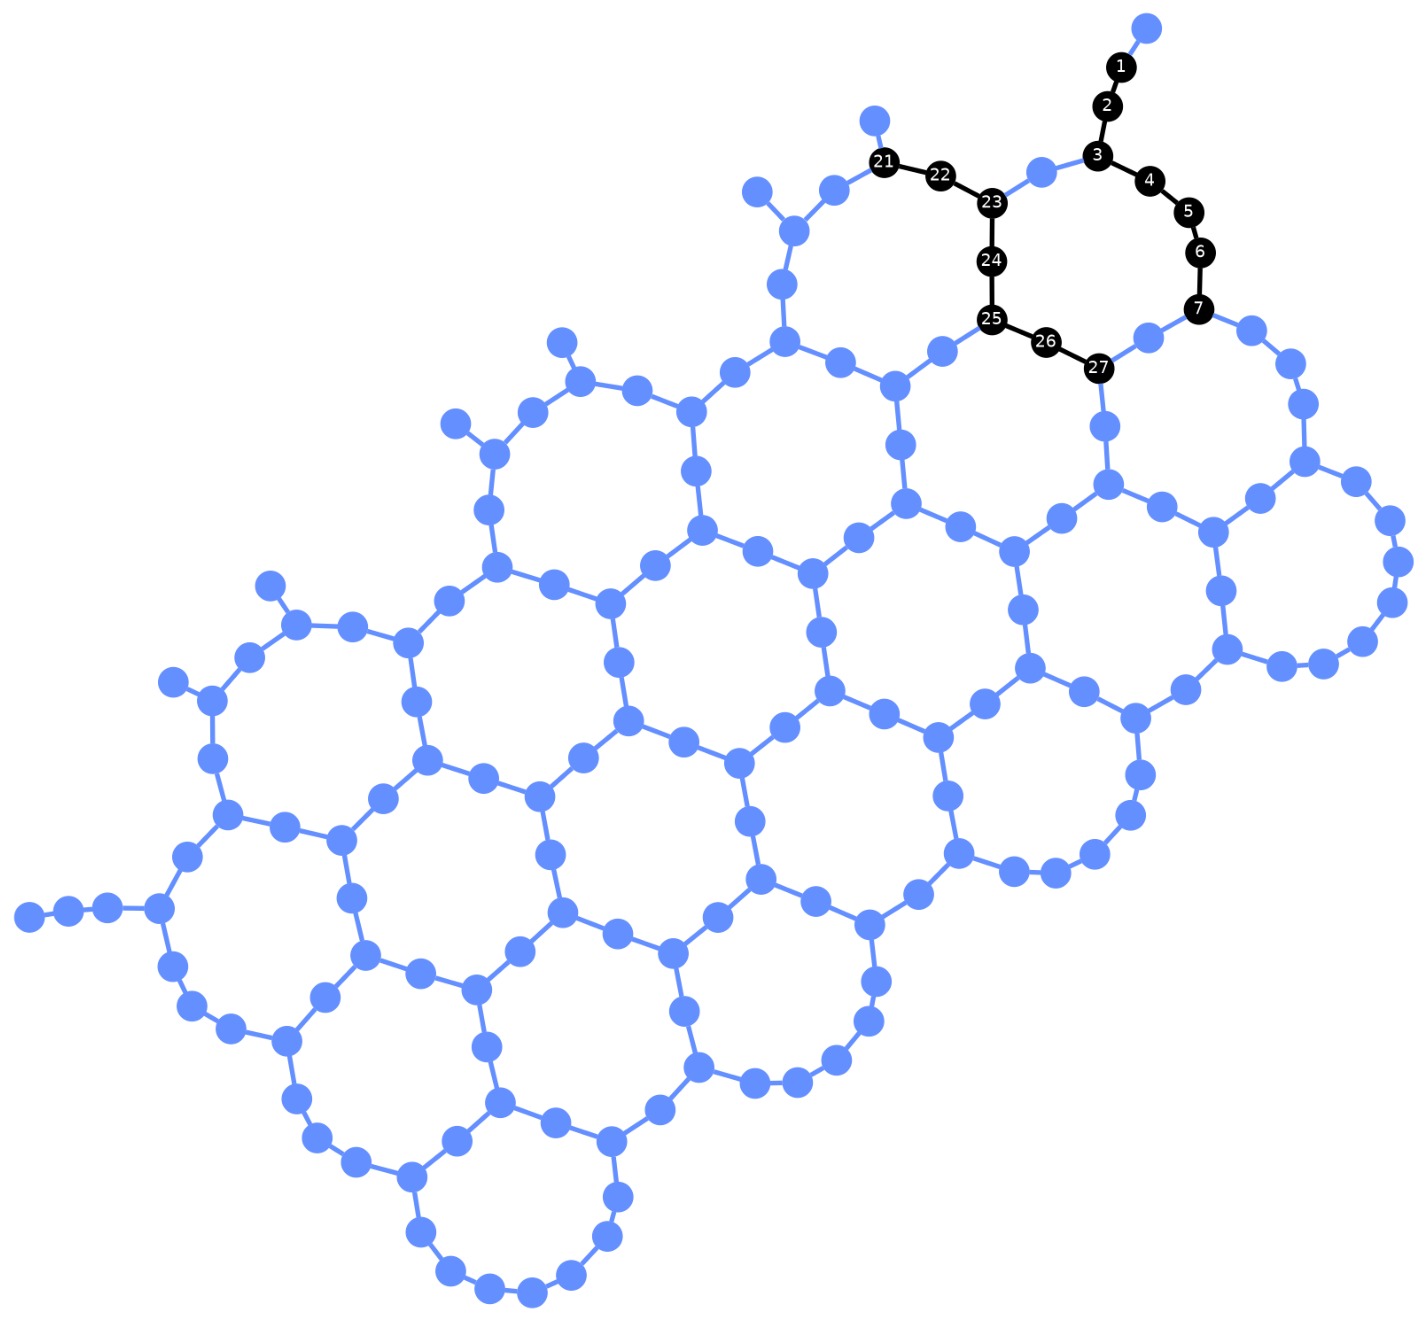

In [29]:
from qiskit.visualization import plot_circuit_layout

plot_circuit_layout(isa_circuit, backend,'physical')

In [30]:
sampler = Sampler(mode=backend)
job = sampler.run([isa_circuit], shots=10_000)

In [31]:
water10_exact_job_id = 'd2d5vu2d065c73fdo6c0'
water183_pred_amps_job_id = 'd2gat450d2ps738vtcr0'
job_dict = {'STO-3G': {'water10': {'exact':'d2d5vu2d065c73fdo6c0'}, 'water183': {'predicted': 'd2gat450d2ps738vtcr0', 'zeroes': 'd2gf0kjibkqs73fbr3qg', 'rand': 'd2gf4i03omtc738hh70g', 'exact': 'd2gfo2tv7m7s73e9mtqg', 'MP2': 'd2gg2buot80s73fcjeig'}}}
init = ['exact', 'zeros', 'rand', 'predicted', 'MP2']
init_method = init[4]

# Use retreived job instead of re running it

In [32]:
# DO NOT RUN THIS FOR water10 STO_3G
primitive_result = job.result()
pub_result = primitive_result[0]

In [33]:
successful_job = next(
    j for j in service.jobs(limit=1000) if j.status() == "DONE"
)
job_id = successful_job.job_id()


In [34]:
print(job_id)
# retrieved_job = service.job(job_id)
# primitive_result = retrieved_job.result()
# pub_result = primitive_result[0]

d2huc7tv7m7s73eb3r30


In [35]:
counts = pub_result.data.meas.get_counts()

from qiskit_addon_sqd.counts import counts_to_arrays

# Convert counts into bitstring and probability arrays
bitstring_matrix_full, probs_arr_full = counts_to_arrays(counts)

In [36]:
fig = plot_circuit_layout(isa_circuit, backend,'physical')
fig.savefig('LUCJ_hardware.svg', dpi=300)

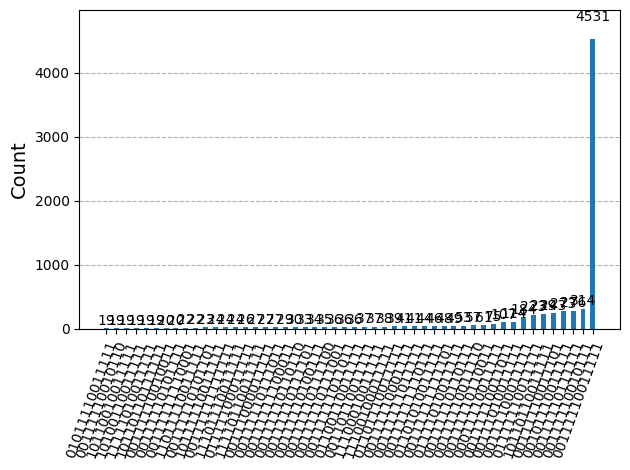

In [37]:
from qiskit.visualization import plot_histogram
plot_histogram(dict(sorted(counts.items(),key=lambda x: x[1])[-50:]), sort='value', target_string=max(counts.items(),key=lambda x: x[1])[0])

In [38]:
import numpy as np
from qiskit_addon_sqd.configuration_recovery import recover_configurations
from qiskit_addon_sqd.fermion import solve_fermion
from qiskit_addon_sqd.subsampling import postselect_and_subsample
import os
# configure jax to use 64 bit mode
import jax
jax.config.update("jax_enable_x64", True)

# tell JAX we are using CPU
jax.config.update('jax_platform_name', 'gpu')


rng = np.random.default_rng(12345)

# SQD options
iterations = 10

# Eigenstate solver options
n_batches = 5
samples_per_batch = 20000
max_davidson_cycles = 200

# Self-consistent configuration recovery loop
e_hist = np.zeros((iterations, n_batches))  # energy history
s_hist = np.zeros((iterations, n_batches))  # spin history
occupancy_hist = []
avg_occupancy = None
for i in range(iterations):
    print(f"Starting configuration recovery iteration {i}")
    # On the first iteration, we have no orbital occupancy information from the
    # solver, so we just post-select from the full bitstring set based on hamming weight.
    if avg_occupancy is None:
        bs_mat_tmp = bitstring_matrix_full
        probs_arr_tmp = probs_arr_full

    # If we have average orbital occupancy information, we use it to refine the full set of noisy configurations
    else:
        bs_mat_tmp, probs_arr_tmp = recover_configurations(
            bitstring_matrix_full,
            probs_arr_full,
            avg_occupancy,
            num_elec_a,
            num_elec_b,
            rand_seed=rng,
        )

    # Throw out configurations with incorrect particle number in either the spin-up or spin-down systems
    batches = postselect_and_subsample(
        bs_mat_tmp,
        probs_arr_tmp,
        hamming_right=num_elec_a,
        hamming_left=num_elec_b,
        samples_per_batch=samples_per_batch,
        num_batches=n_batches,
        rand_seed=rng,
    )

    # Run eigenstate solvers in a loop. This loop should be parallelized for larger problems.
    e_tmp = np.zeros(n_batches)
    s_tmp = np.zeros(n_batches)
    occs_tmp = []
    coeffs = []
    for j in range(n_batches):
        energy_sci, coeffs_sci, avg_occs, spin = solve_fermion(
            batches[j],
            hcore,
            eri,
            open_shell=open_shell,
            spin_sq=spin_sq,
            # max_davidson=max_davidson_cycles,
        )
        energy_sci += nuclear_repulsion_energy
        e_tmp[j] = energy_sci
        s_tmp[j] = spin
        occs_tmp.append(avg_occs)
        coeffs.append(coeffs_sci)

    # Combine batch results
    avg_occupancy = np.mean(occs_tmp, axis=0)

    # Track optimization history
    e_hist[i, :] = e_tmp
    s_hist[i, :] = s_tmp
    occupancy_hist.append(avg_occupancy)

Starting configuration recovery iteration 0
Starting configuration recovery iteration 1
Starting configuration recovery iteration 2
Starting configuration recovery iteration 3
Starting configuration recovery iteration 4
Starting configuration recovery iteration 5
Starting configuration recovery iteration 6
Starting configuration recovery iteration 7
Starting configuration recovery iteration 8
Starting configuration recovery iteration 9


In [39]:
def pad_to_full_space(active_occ: np.ndarray, full_occ: np.ndarray) -> np.ndarray:
    """
    Pad the active-space occupation array with zeros so that it
    matches the length of the full-space occupation array.

    Parameters
    ----------
    active_occ : np.ndarray
        Occupation numbers for active orbitals (1D array).
    full_occ : np.ndarray
        Occupation numbers for all orbitals (1D array).
    
    Returns
    -------
    np.ndarray
        Occupation numbers extended to the full space.
    """
    n_active = len(active_occ)
    n_full = len(full_occ)
    if n_active > n_full:
        raise ValueError("Active occupation array longer than full occupation array.")

    padded = np.zeros(n_full, dtype=active_occ.dtype)
    padded[:n_active] = active_occ
    return padded


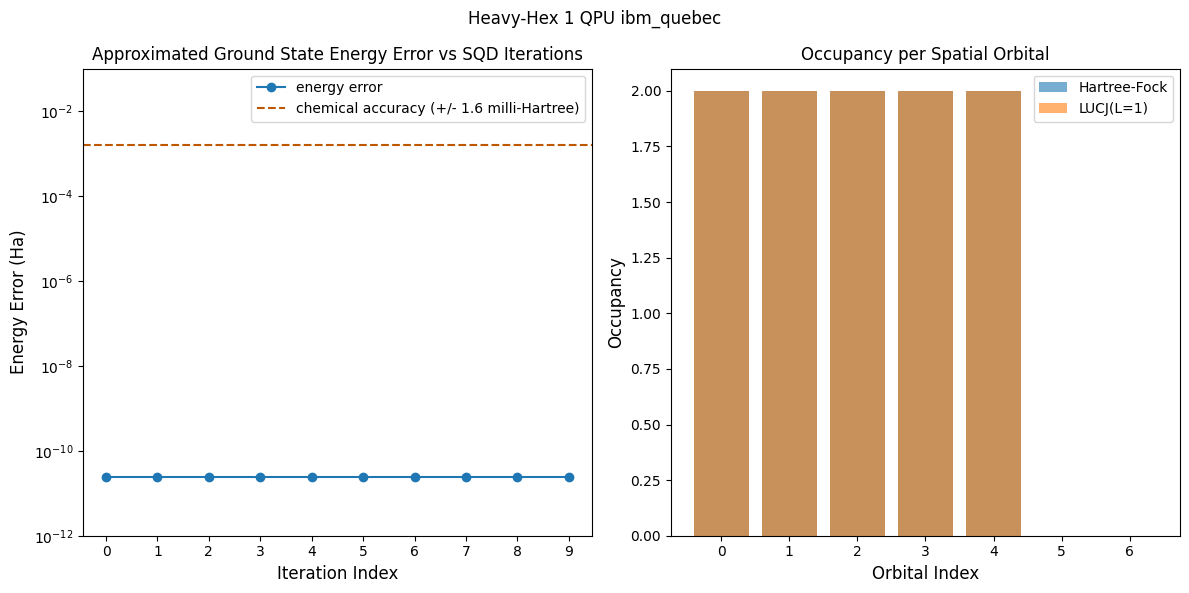

In [40]:
# Data for energies plot
x1 = range(iterations)
e_diff = [abs(np.min(energies) - exact_energy) for energies in e_hist]
yt1 = [1.0, 1e-1, 1e-2, 1e-3, 1e-4]

# Chemical accuracy (+/- 1 milli-Hartree)
chem_accuracy = 0.0016

# Data for avg spatial orbital occupancy
y2 = occupancy_hist[-1][0] + occupancy_hist[-1][1]
if (len(y2) < len(scf.mo_occ)):
    y2_prime = pad_to_full_space(y2, scf.mo_occ)
x2 = range(len(y2))
fig, axs = plt.subplots(1, 2, figsize=(12, 6))

# Plot energies
axs[0].plot(x1, e_diff, label="energy error", marker="o")
axs[0].set_xticks(x1)
axs[0].set_xticklabels(x1)
axs[0].set_yticks(yt1)
axs[0].set_yticklabels(yt1)
axs[0].set_yscale("log")
axs[0].set_ylim(1e-12,1e-1)
axs[0].axhline(y=chem_accuracy, color="#BF5700", linestyle="--", label="chemical accuracy (+/- 1.6 milli-Hartree)")
axs[0].set_title("Approximated Ground State Energy Error vs SQD Iterations")
axs[0].set_xlabel("Iteration Index", fontdict={"fontsize": 12})
axs[0].set_ylabel("Energy Error (Ha)", fontdict={"fontsize": 12})
axs[0].legend()

# Plot orbital occupancy
axs[1].bar(x2, scf.mo_occ[:len(y2)], width=0.8,alpha=0.6,label='Hartree-Fock')
axs[1].bar(x2, y2, width=0.8,alpha=0.6,label='LUCJ(L=1)')
axs[1].legend()
axs[1].set_xticks(x2)
axs[1].set_xticklabels(x2)
axs[1].set_title("Occupancy per Spatial Orbital")
axs[1].set_xlabel("Orbital Index", fontdict={"fontsize": 12})
axs[1].set_ylabel("Occupancy", fontdict={"fontsize": 12})
plt.suptitle(f'Heavy-Hex 1 QPU {backend.name}')
plt.tight_layout()
plt.savefig(f"results/{basis}/{init_method}2_H2O_{basis}_CAS({sum(nelec)},{num_orbitals}).png",dpi=300,bbox_inches='tight')
#plt.savefig("H2O_STO3G_CAS(10,8).png",dpi=300,bbox_inches='tight')
plt.show()

In [41]:
def log_results(
    basis: str,
    molecule: str,
    mol_file: str,
    n_frozen: int,
    num_orbitals: int,
    n_electrons: int,
    init_method: str,
    job_id: str | None = None,
    e_diff: list[float] | None = None,
    y2: list[float] | None = None,
    path: str = "logs/sqd_runs.csv",
) -> pd.DataFrame:
    """
    Log quantum chemistry run parameters and results into a DataFrame.
    Will append to an existing CSV (creating it if needed).

    Parameters
    ----------
    basis : str
        Basis set name (e.g., "sto-3g")
    molecule : str
        Molecule identifier (formula, SMILES, etc.)
    mol_file : str
        Path to the molecule file (e.g., "h2.xyz")
    n_frozen : int
        Number of frozen orbitals
    num_orbitals : int
        Number of orbitals
    n_electrons : int
        Number of electrons
    init_method : str
        Initialization method: one of ["exact", "zeros", "rand", "predicted", "MP2"]
    job_id : str, optional
        Job ID (from Qiskit, or autogenerated if None)
    e_diff : list[float], optional
        List of energy differences
    y2 : list[float], optional
        List of y2 values
    path : str, optional
        Path to CSV log file (default "logs/qchem_runs.csv")

    Returns
    -------
    df : pd.DataFrame
        The updated DataFrame including this run
    """
    os.makedirs(os.path.dirname(path) or ".", exist_ok=True)

    if job_id is None:
        job_id = "local-" + uuid.uuid4().hex[:8]

    row = {
        "basis": basis,
        "molecule": molecule,
        "mol_file": mol_file,
        "n_frozen": n_frozen,
        "num_orbitals": num_orbitals,
        "n_electrons": n_electrons,
        "init_method": init_method,
        "job_id": job_id,
        "e_diff": e_diff if e_diff is not None else [],
        "y2": y2 if y2 is not None else [],
    }

    df_new = pd.DataFrame([row])

    if os.path.exists(path):
        df_old = pd.read_csv(path)
        df = pd.concat([df_old, df_new], ignore_index=True)
    else:
        df = df_new

    df.to_csv(path, index=False)
    return df

In [42]:
df_test = log_results(basis, molecule, mol_file, n_frozen, num_orbitals, n_electrons, init_method, job_id, e_diff, y2)